In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('insurance.csv')

In [3]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


EDA


In [4]:
df.shape

(1338, 7)

In [5]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [8]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [9]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [10]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

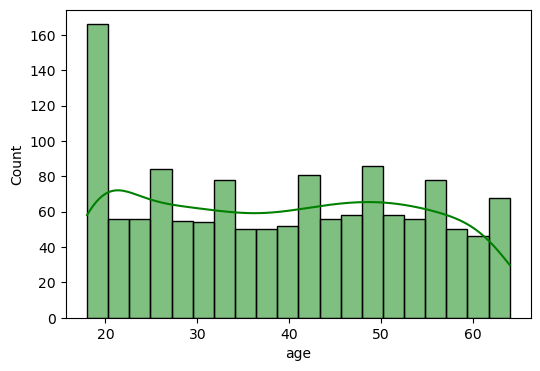

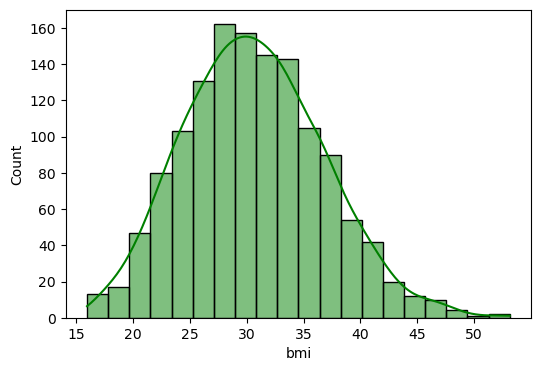

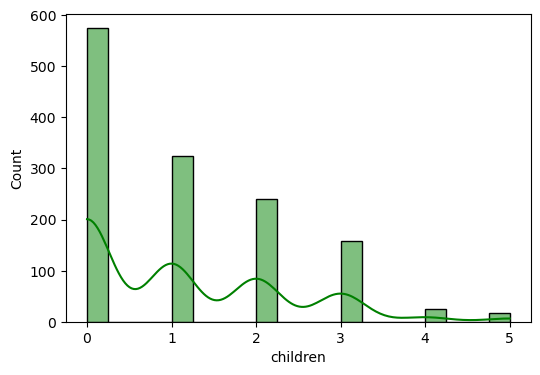

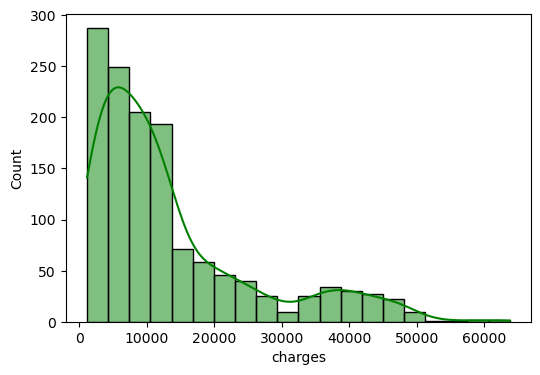

In [11]:
numeric_columns = ['age', 'bmi', 'children',  'charges']
for col in numeric_columns:
    plt.figure(figsize = (6,4))
    sns.histplot(df[col],kde = True,  bins = 20,color = 'green')

<Axes: xlabel='children', ylabel='count'>

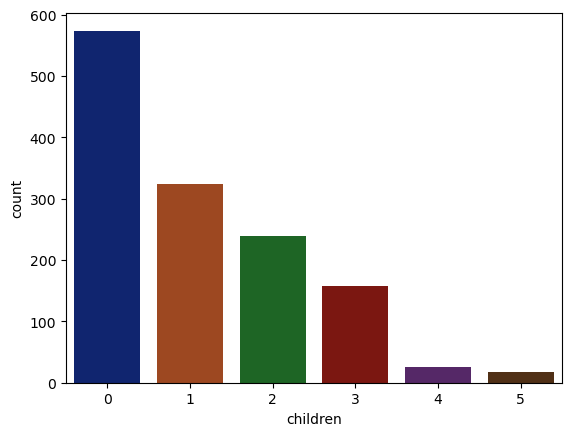

In [12]:
sns.countplot(x = df['children'],palette = 'dark')

<Axes: xlabel='sex', ylabel='count'>

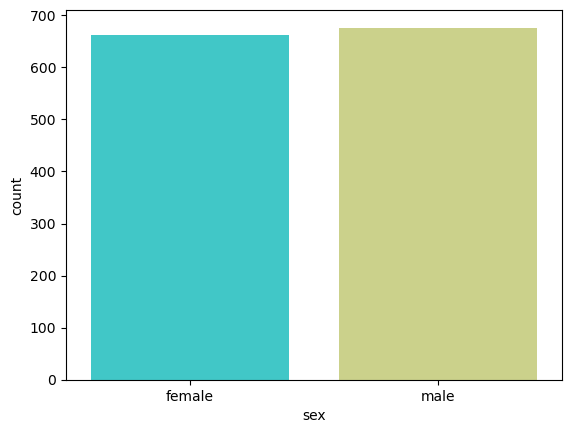

In [13]:
sns.countplot(x= df['sex'],palette = 'rainbow')

<Axes: xlabel='smoker', ylabel='count'>

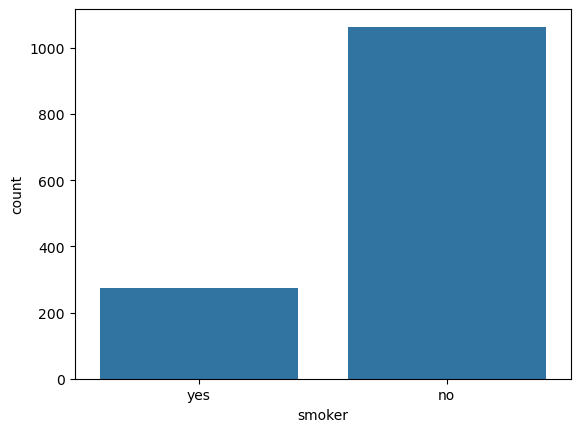

In [14]:
sns.countplot(x = df['smoker'])

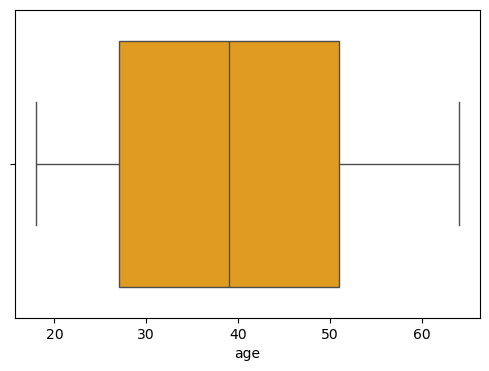

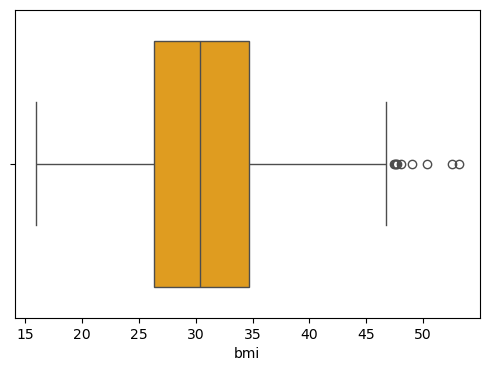

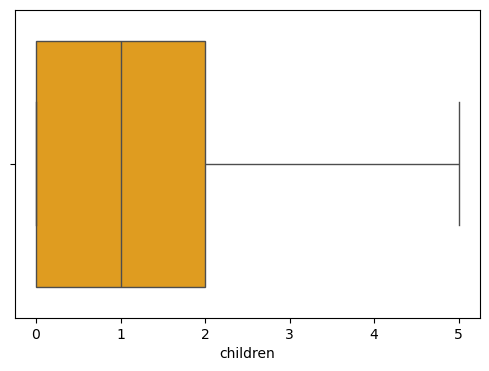

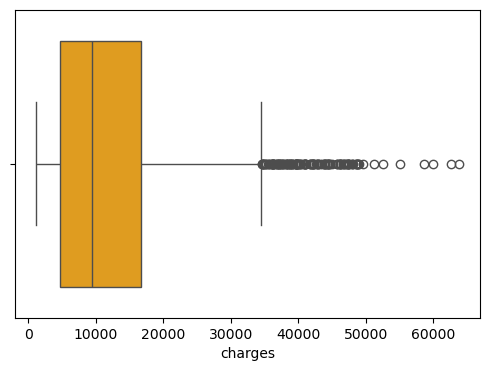

In [15]:
for col in numeric_columns:
    plt.figure(figsize = (6,4))
    sns.boxplot(x= df[col],color = 'orange')

<Axes: >

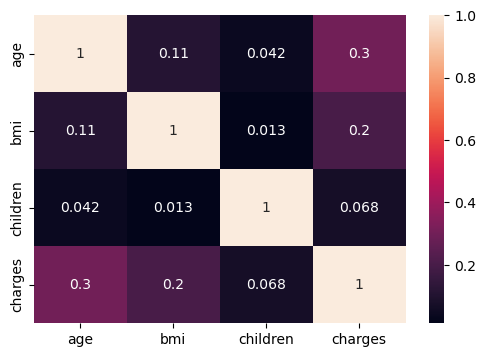

In [16]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only = True),annot = True)

### DATA CLEANING AND PREPROCESSING ###

In [17]:
df2 = df.copy()

In [18]:
df2.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [19]:
df2.drop_duplicates(inplace = True)

In [20]:
df2.shape


(1337, 7)

In [21]:
df2.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [22]:
df2.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [23]:
df['sex'].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

In [24]:
df2['sex'] = df2['sex'].map({"male":0, "female":1})

In [25]:
df2.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [26]:
df2['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [27]:
df2['smoker'] = df2['smoker'].map({"no":0, "yes":1})

In [28]:
df2

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,northwest,10600.54830
1334,18,1,31.920,0,0,northeast,2205.98080
1335,18,1,36.850,0,0,southeast,1629.83350
1336,21,1,25.800,0,0,southwest,2007.94500


In [29]:
df2.rename(columns = {
    'sex':"is_female",
    "smoker":"is_smoker"
},inplace = True)

In [30]:
df2

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,northwest,10600.54830
1334,18,1,31.920,0,0,northeast,2205.98080
1335,18,1,36.850,0,0,southeast,1629.83350
1336,21,1,25.800,0,0,southwest,2007.94500


In [31]:
df2['region'].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

### using one hot encoding ###

In [32]:
df2 = pd.get_dummies(df2,columns = ['region'],drop_first = False)

In [33]:
df2

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,False,True
1,18,0,33.770,1,0,1725.55230,False,False,True,False
2,28,0,33.000,3,0,4449.46200,False,False,True,False
3,33,0,22.705,0,0,21984.47061,False,True,False,False
4,32,0,28.880,0,0,3866.85520,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,False,True,False,False
1334,18,1,31.920,0,0,2205.98080,True,False,False,False
1335,18,1,36.850,0,0,1629.83350,False,False,True,False
1336,21,1,25.800,0,0,2007.94500,False,False,False,True


In [34]:
df2  = df2.astype(int)

In [35]:
df2

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,0,1
1,18,0,33,1,0,1725,0,0,1,0
2,28,0,33,3,0,4449,0,0,1,0
3,33,0,22,0,0,21984,0,1,0,0
4,32,0,28,0,0,3866,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,0,1,0,0
1334,18,1,31,0,0,2205,1,0,0,0
1335,18,1,36,0,0,1629,0,0,1,0
1336,21,1,25,0,0,2007,0,0,0,1


### FEATURE ENGINEERING AND EXTRACTION ###

<Axes: xlabel='bmi', ylabel='Count'>

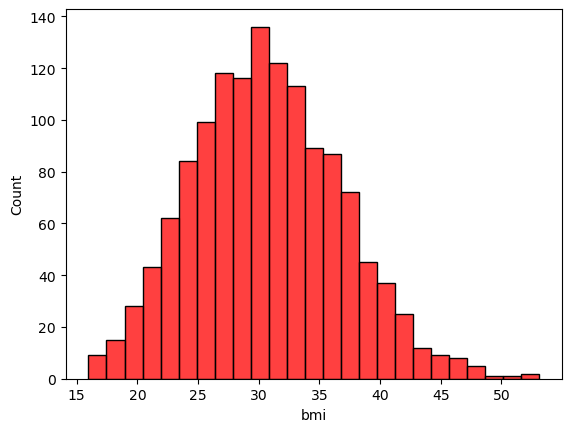

In [36]:
sns.histplot(df['bmi'],color='red')

In [37]:
df2['bmi_cat'] = pd.cut(
    df2['bmi'],
    bins = [0,18.5,24.5,29.9,float('inf')],
    labels = ['underweight','normal','overweight','obese']
)

In [38]:
df2

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_cat
0,19,1,27,0,1,16884,0,0,0,1,overweight
1,18,0,33,1,0,1725,0,0,1,0,obese
2,28,0,33,3,0,4449,0,0,1,0,obese
3,33,0,22,0,0,21984,0,1,0,0,normal
4,32,0,28,0,0,3866,0,1,0,0,overweight
...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,0,1,0,0,obese
1334,18,1,31,0,0,2205,1,0,0,0,obese
1335,18,1,36,0,0,1629,0,0,1,0,obese
1336,21,1,25,0,0,2007,0,0,0,1,overweight


<Axes: xlabel='bmi_cat', ylabel='Count'>

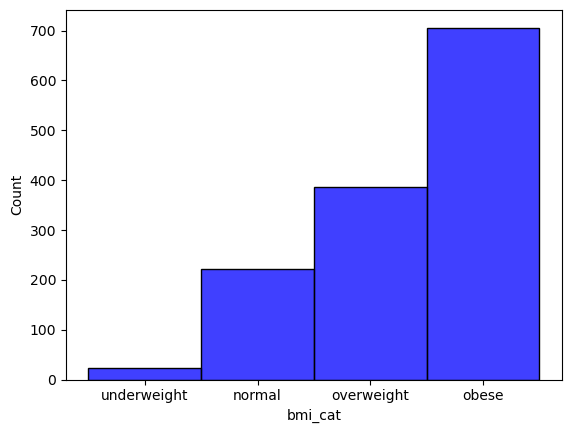

In [39]:
sns.histplot(data=df2, x='bmi_cat',color='blue')

In [40]:
df2 = pd.get_dummies(df2,columns=['bmi_cat'],drop_first =False)

In [41]:
df2 = df2.astype(int)

In [42]:
df2

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_cat_underweight,bmi_cat_normal,bmi_cat_overweight,bmi_cat_obese
0,19,1,27,0,1,16884,0,0,0,1,0,0,1,0
1,18,0,33,1,0,1725,0,0,1,0,0,0,0,1
2,28,0,33,3,0,4449,0,0,1,0,0,0,0,1
3,33,0,22,0,0,21984,0,1,0,0,0,1,0,0
4,32,0,28,0,0,3866,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,0,1,0,0,0,0,0,1
1334,18,1,31,0,0,2205,1,0,0,0,0,0,0,1
1335,18,1,36,0,0,1629,0,0,1,0,0,0,0,1
1336,21,1,25,0,0,2007,0,0,0,1,0,0,1,0


In [43]:
df2.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_cat_underweight,bmi_cat_normal,bmi_cat_overweight,bmi_cat_obese
0,19,1,27,0,1,16884,0,0,0,1,0,0,1,0
1,18,0,33,1,0,1725,0,0,1,0,0,0,0,1
2,28,0,33,3,0,4449,0,0,1,0,0,0,0,1
3,33,0,22,0,0,21984,0,1,0,0,0,1,0,0
4,32,0,28,0,0,3866,0,1,0,0,0,0,1,0


### FEATURE SCALING ###

In [44]:
df2.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'bmi_cat_underweight', 'bmi_cat_normal',
       'bmi_cat_overweight', 'bmi_cat_obese'],
      dtype='object')

In [45]:
from sklearn.preprocessing import StandardScaler
cols = ['age','bmi','children']
scalar = StandardScaler()
df2[cols] = scalar.fit_transform(df2[cols])

In [46]:
df2.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_cat_underweight,bmi_cat_normal,bmi_cat_overweight,bmi_cat_obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,0,1,0,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,0,1,0,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,0,1,0,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,0,1,0,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,0,1,0,0,0,0,1,0


### FEATURE EXTRACTION ###

In [47]:
from scipy.stats import pearsonr

selected_features = ['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'bmi_cat_underweight', 'bmi_cat_normal',
       'bmi_cat_overweight', 'bmi_cat_obese']

correlations = {
    feature: pearsonr(df2[feature], df2['charges'])[0]
    for feature in selected_features
}
correlation_df = pd.DataFrame(list(correlations.items()), columns = ['feature', 'pearson_correlation' ])
correlation_df.sort_values(by='pearson_correlation', ascending= False)


,feature,pearson_correlation
5,charges,1.000000
4,is_smoker,0.787234
0,age,0.298309
13,bmi_cat_obese,0.200348
2,bmi,0.196236
8,region_southeast,0.073577
3,children,0.067390
6,region_northeast,0.005946
7,region_northwest,-0.038695
9,region_southwest,-0.043637


In [48]:
correlation_df

,feature,pearson_correlation
0,age,0.298309
1,is_female,-0.058046
2,bmi,0.196236
3,children,0.067390
4,is_smoker,0.787234
5,charges,1.000000
6,region_northeast,0.005946
7,region_northwest,-0.038695
8,region_southeast,0.073577
9,region_southwest,-0.043637


In [49]:
cat_features = [ 'is_female',  'is_smoker',
                     'region_northeast', 'region_northwest', 'region_southeast',
                     'region_southwest', 'bmi_cat_underweight', 'bmi_cat_normal',
                     'bmi_cat_overweight', 'bmi_cat_obese'
    
]

In [50]:
from scipy.stats import chi2_contingency
import pandas as pd


alpha = 0.05
df2['charges_bins'] = pd.qcut(df2['charges'],q=4,labels=False)
chi2_results = {}

for col in cat_features:
    contingency = pd.crosstab(df2[col],df2['charges_bins'])
    chi2_stat,p_val,_,_ = chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop feature )'
    chi2_results[col]={
        'chi2_statistics' : chi2_stat,
        'p_value' : p_val,
        'decision' : decision
    }

chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by = 'p_value')
chi2_df



,chi2_statistics,p_value,decision
is_smoker,848.219178,0.0,Reject Null (Keep Feature)
region_southeast,15.998167,0.001135,Reject Null (Keep Feature)
is_female,10.258784,0.01649,Reject Null (Keep Feature)
bmi_cat_obese,8.515711,0.036473,Reject Null (Keep Feature)
region_northeast,6.438442,0.092122,Accept Null (Drop feature )
region_southwest,5.091893,0.165191,Accept Null (Drop feature )
bmi_cat_overweight,4.25149,0.235557,Accept Null (Drop feature )
bmi_cat_normal,3.708088,0.29476,Accept Null (Drop feature )
bmi_cat_underweight,3.37403,0.337471,Accept Null (Drop feature )
region_northwest,1.13424,0.768815,Accept Null (Drop feature )


In [58]:
final_df = df2[['age', 'is_female', 'bmi', 'children', 'is_smoker','charges'
                ,'region_southeast', 'region_southwest', 'bmi_cat_obese']]


In [59]:
final_df.head()

,age,is_female,bmi,children,is_smoker,charges,region_southeast,region_southwest,bmi_cat_obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,1,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,1,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,0,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,0,0,0
